In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.feature_selection import SelectKBest, f_classif

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [6]:
label_df = df.copy()

le = LabelEncoder()

label_df["Sex_Label"] = le.fit_transform(label_df["Sex"])

label_df[["Sex", "Sex_Label"]].head()

,Sex,Sex_Label
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


In [7]:
onehot = pd.get_dummies(df, columns=["Embarked"], dtype=int)

onehot.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0,0,1


In [8]:
ordinal = OrdinalEncoder(categories=[["S", "C", "Q"]])

df["Embarked_Ordinal"] = ordinal.fit_transform(df[["Embarked"]])

df[["Embarked", "Embarked_Ordinal"]].head()

,Embarked,Embarked_Ordinal
0,S,0.0
1,C,1.0
2,S,0.0
3,S,0.0
4,S,0.0


In [9]:
features = df[["Age", "Fare"]]

standard = StandardScaler()
minmax = MinMaxScaler()
robust = RobustScaler()

std_scaled = standard.fit_transform(features)
mm_scaled = minmax.fit_transform(features)
rb_scaled = robust.fit_transform(features)

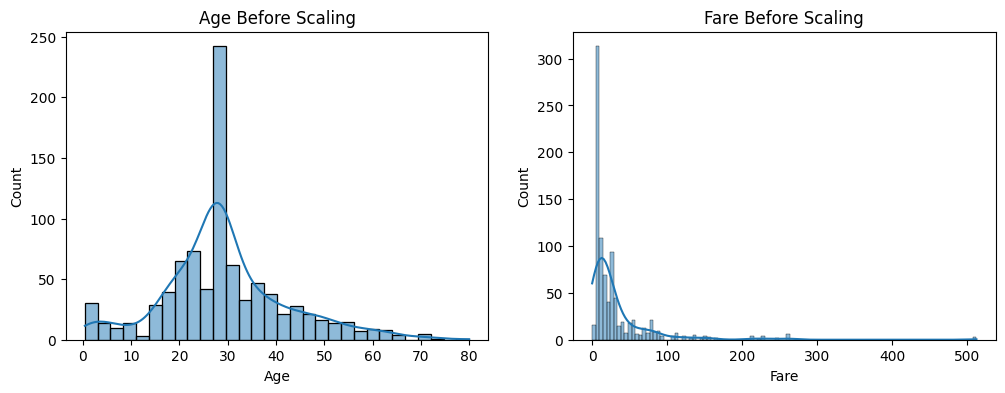

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df["Age"], kde=True)
plt.title("Age Before Scaling")

plt.subplot(1,2,2)
sns.histplot(df["Fare"], kde=True)
plt.title("Fare Before Scaling")

plt.show()

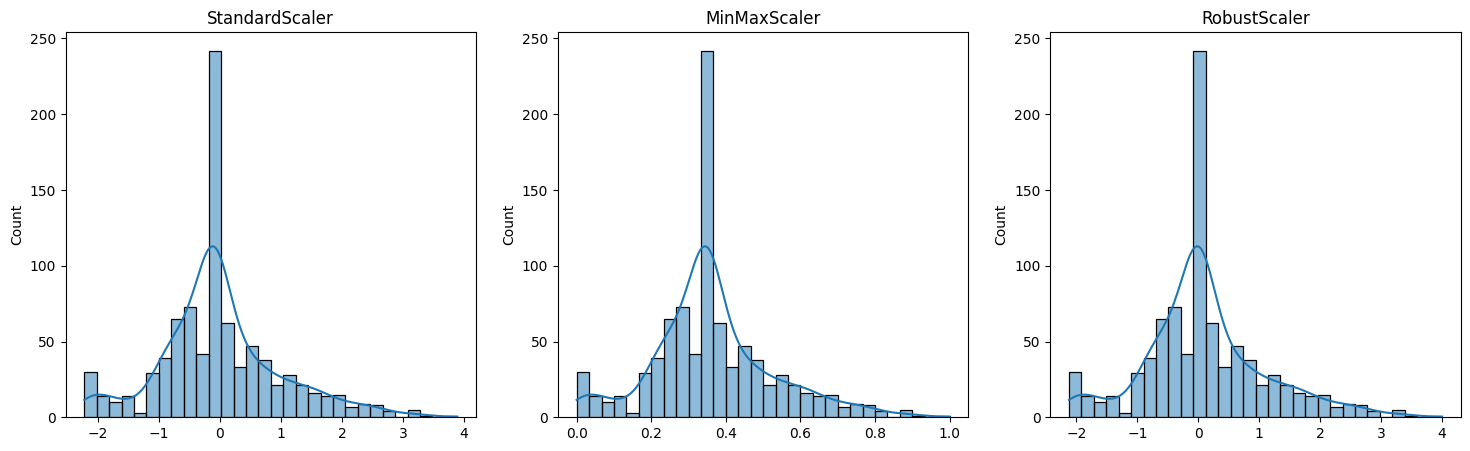

In [11]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(std_scaled[:,0], kde=True, ax=axes[0])
axes[0].set_title("StandardScaler")

sns.histplot(mm_scaled[:,0], kde=True, ax=axes[1])
axes[1].set_title("MinMaxScaler")

sns.histplot(rb_scaled[:,0], kde=True, ax=axes[2])
axes[2].set_title("RobustScaler")

plt.show()

In [12]:
feature_df = df.copy()

feature_df = pd.get_dummies(feature_df, drop_first=True)

X = feature_df.drop("Survived", axis=1)
y = feature_df["Survived"]

selector = SelectKBest(score_func=f_classif, k=5)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Top 5 Features:")
print(selected_features)

Top 5 Features:
Index(['Pclass', 'Fare', 'Embarked_Ordinal', 'Sex_male', 'Embarked_S'], dtype='object')


In [13]:
scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

scores.sort_values(by="Score", ascending=False).head()

,Feature,Score
897,Sex_male,372.405724
1,Pclass,115.031272
5,Fare,63.030764
1725,Embarked_S,20.374460
6,Embarked_Ordinal,10.259355
